In [30]:
import numpy as np
import pandas as pd
import tensorflow as tf
import json
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils import class_weight


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping

import nltk
from nltk.stem import WordNetLemmatizer


import matplotlib as plt

In [31]:
data = pd.read_csv('../data/blooms_taxonomy_dataset.csv', encoding='latin-1')

data["Questions"] = data["Questions"].str.lower().str.replace(r'[^\w\s]', '', regex=True)

X = data["Questions"]
y = data["Category"]

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
num_classes = len(np.unique(y_encoded))

print(f"Detected {num_classes} classes: {label_encoder.classes_}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42
)

Detected 6 classes: ['BT1' 'BT2' 'BT3' 'BT4' 'BT5' 'BT6']


In [32]:
vectorizer = TfidfVectorizer(max_features=2000, ngram_range=(1,3))
X_train_tfidf = vectorizer.fit_transform(X_train).toarray()
X_test_tfidf = vectorizer.transform(X_test).toarray()




In [33]:
model = Sequential([
    Dense(128, activation='relu', kernel_regularizer=l2(0.01), input_shape=(X_train_tfidf.shape[1],)),
    BatchNormalization(),
    Dropout(0.6),
    Dense(64, activation='relu', kernel_regularizer=l2(0.01)),
    BatchNormalization(),
    Dropout(0.6),
    Dense(num_classes, activation='softmax')
])

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [34]:
model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss=SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

In [35]:
weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
dict_weights = dict(enumerate(weights))

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("Training Bloom's Taxonomy Model...")
history = model.fit(
    X_train_tfidf, y_train,
    epochs=20,
    validation_data=(X_test_tfidf, y_test),
    callbacks=[early_stop],
    class_weight=dict_weights,
    verbose=1
)

Training Bloom's Taxonomy Model...
Epoch 1/20
372/372 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.4176 - loss: 3.7636 - val_accuracy: 0.4286 - val_loss: 3.1888
Epoch 2/20
372/372 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6712 - loss: 2.4824 - val_accuracy: 0.8222 - val_loss: 1.9623
Epoch 3/20
372/372 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7662 - loss: 1.9058 - val_accuracy: 0.8434 - val_loss: 1.5608
Epoch 4/20
372/372 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7978 - loss: 1.5220 - val_accuracy: 0.8589 - val_loss: 1.2887
Epoch 5/20
372/372 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8269 - loss: 1.2322 - val_accuracy: 0.8566 - val_loss: 1.0945
Epoch 6/20
372/372 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8324 - loss: 1.0488 - val_accuracy: 0.8505 - val_loss: 0.9752
Epoch 7/20
372/372 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8411 - loss: 0.9255 - val_accuracy: 0.8626 - val_loss: 0.8729
Epoch 8/20
372/372 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.852

In [36]:

with open('../data/co_mapping.json', 'r') as f:
    config = json.load(f)
print("done")


done


In [37]:
def analyze_question(question_text):
    clean_q = re.sub(r'[^\w\s]', '', question_text.lower())
    bloom_level = label_encoder.inverse_transform([np.argmax(model.predict(
        vectorizer.transform([clean_q]).toarray(), verbose=0))])[0]

    def get_best_match(items):
        if not items: return "N/A", 0
        match = max(items.items(), key=lambda x: sum(kw.lower() in clean_q for kw in x[1]['keywords']), default=("N/A", 0))
        score = sum(kw.lower() in clean_q for kw in match[1]['keywords']) if isinstance(match[1], dict) else 0
        return (match[0], score) if score > 0 else ("N/A", 0)

    subject, sub_score = get_best_match(config.get('subjects', {}))
    co_id, _ = get_best_match(config.get('co_mappings', {}).get(subject, {})) if sub_score > 0 else ("N/A", 0)

    return {
        "original_question": question_text,
        "bloom_level": bloom_level,
        "subject": subject if sub_score > 0 else "General/Unknown",
        "co_id": co_id
    }


In [38]:
loss, accuracy = model.evaluate(X_test_tfidf, y_test)
print(f"Test Accuracy: {accuracy*100:.2f}%")

93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 501us/step - accuracy: 0.8633 - loss: 0.7166
Test Accuracy: 86.33%


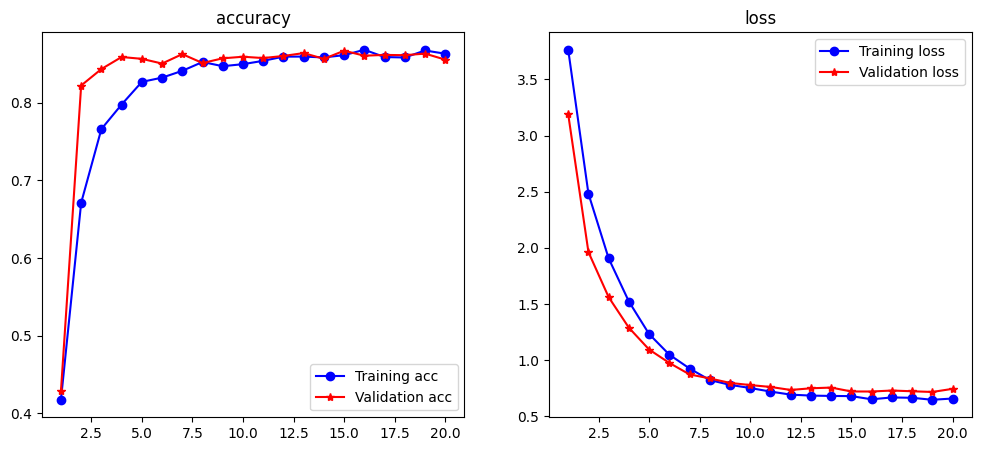

In [39]:
import matplotlib.pyplot as plt

def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'bo-', label='Training acc')
    plt.plot(epochs, val_acc, 'r*-', label='Validation acc')
    plt.title('accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'bo-', label='Training loss')
    plt.plot(epochs, val_loss, 'r*-', label='Validation loss')
    plt.title('loss')
    plt.legend()

    plt.show()

plot_history(history)

In [ ]:
import pickle
model.save('bloom_model.h5')

with open('vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f) 

with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

print("saved")

All files saved successfully!
